# Data Quality Analysis — `alpaca_data_cleaned-dutch.jsonl`

Checks:
1. Basic stats & completeness
2. Duplicate detection
3. Language quality (English leakage)
4. Token length distributions (input & output) using the Mistral tokenizer
5. Combined sequence lengths vs. `max_seq_length`

In [18]:
import json, re, warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

DATA_PATH = Path("datasets/alpaca_data_cleaned-dutch.jsonl")

records = []
bad_lines = []

with DATA_PATH.open("r", encoding="utf-8") as f:
	for i, line in enumerate(f, start=1):
		line = line.strip()
		if not line:
			continue
		try:
			records.append(json.loads(line))
		except json.JSONDecodeError:
			bad_lines.append(i)

df = pd.DataFrame(records)

print(f"Loaded {len(df):,} valid rows  |  Columns: {list(df.columns)}")
if bad_lines:
	print(f"Skipped {len(bad_lines):,} malformed JSONL lines (first 10: {bad_lines[:10]})")

df.head(3)

Loaded 51,711 valid rows  |  Columns: ['id', 'instruction', 'input', 'output']


,id,instruction,input,output
0,1,Geef drie tips om gezond te blijven.,,1. Eet een gebalanceerd dieet en zorg ervoor d...
1,2,Wat zijn de drie primaire kleuren?,,"De drie primaire kleuren zijn rood, blauw en g..."
2,3,Beschrijf de structuur van een atoom.,,"Een atoom bestaat uit een kern, die protonen e..."


## 1. Basic Stats & Completeness

In [2]:
# Missing / empty fields
print("=== Missing or empty fields ===")
for col in ["instruction", "input", "output"]:
    n_missing = df[col].isna().sum()
    n_empty = (df[col].fillna("").str.strip() == "").sum()
    print(f"  {col:>12s}:  missing={n_missing:,}  empty={n_empty:,}")

# Character-level length stats
print("\n=== Character length stats ===")
for col in ["instruction", "input", "output"]:
    lengths = df[col].fillna("").str.len()
    print(f"  {col:>12s}:  min={lengths.min():>5,}  median={lengths.median():>6,.0f}  mean={lengths.mean():>6,.0f}  max={lengths.max():>6,}")

# Very short outputs
short_outputs = df[df["output"].str.len() <= 5]
print(f"\nVery short outputs (≤5 chars): {len(short_outputs):,} ({100*len(short_outputs)/len(df):.1f}%)")
short_outputs[["id", "instruction", "output"]].head(10)

=== Missing or empty fields ===
   instruction:  missing=0  empty=0
         input:  missing=0  empty=32,684
        output:  missing=0  empty=0

=== Character length stats ===
   instruction:  min=    9  median=    63  mean=    68  max= 1,235
         input:  min=    0  median=     0  mean=    26  max= 3,015
        output:  min=    1  median=   219  mean=   312  max= 3,913

Very short outputs (≤5 chars): 925 (1.8%)


,id,instruction,output
80,81,Classificeer het volgende incident als een sch...,1
98,99,Classificeer de volgende uitspraak als waar of...,Waar.
121,122,Converteer de temperatuur van Fahrenheit naar ...,"34,4C"
152,153,"Gegeven een array van integers, retourneer het...",6
153,154,Vind de twee niet-herhalende elementen in een ...,"7, 9"
155,156,Vind de maximale winst die kan worden behaald ...,865
207,208,Vind het laagste gemeenschappelijke veelvoud v...,30932
209,210,Converteer het volgende hexadecimale getal naa...,333
224,225,"Genereer het derde termijn in de reeks 2, 5, 9...",18
228,229,Identificeer het onjuiste woord in deze zin.,hun


## 2. Duplicate Detection

In [3]:
n_dup_instr = df.duplicated(subset=["instruction"], keep=False).sum()
n_dup_instr_input = df.duplicated(subset=["instruction", "input"], keep=False).sum()
n_dup_output = df.duplicated(subset=["output"], keep=False).sum()

print(f"Duplicate instructions:              {n_dup_instr:>5,}")
print(f"Duplicate (instruction + input):     {n_dup_instr_input:>5,}")
print(f"Duplicate outputs:                   {n_dup_output:>5,}")

# Show some duplicate instructions
dup_instrs = df[df.duplicated(subset=["instruction"], keep=False)].sort_values("instruction")
if len(dup_instrs) > 0:
    print(f"\nSample duplicate instructions:")
    for instr in dup_instrs["instruction"].unique()[:5]:
        count = (df["instruction"] == instr).sum()
        print(f"  [{count}x] {instr[:100]}")

Duplicate instructions:                 78
Duplicate (instruction + input):        37
Duplicate outputs:                   1,262

Sample duplicate instructions:
  [2x] Als x+y = 6 en x^2-y^2 = 12, wat is dan x-y?
  [2x] Beantwoord de volgende vraag door stap voor stap te redeneren.
  [2x] Beantwoord deze vraag met ja of nee.
  [2x] De Happy Valley Kennel heeft 4 kippen, 2 honden en 5 katten. (Sommige mensen in Happy Valley houden 
  [2x] Gebruik de volgende context om de vraag aan het einde te beantwoorden. Als je het antwoord niet weet


## 3. Language Quality — English Leakage

In [4]:
# English-only words (not shared with Dutch)
ENGLISH_ONLY = re.compile(
    r"\b(the|this|and|for|with|that|from|have|has|will|but|which|also|been"
    r"|would|should|could|their|there|were|more|other|than|then|when|what"
    r"|about|into|only|some|such|each|these|those|between|after|before"
    r"|during|through|because|however|although|while|since|where|both"
    r"|most|many|very|just|even|still|already|always|never|often"
    r"|Here|Below|Step|Note|Example|Output|Input|Answer"
    r"|However|Therefore|Furthermore|Additionally|Moreover|Overall)\b"
)

df["eng_words"] = df["output"].apply(lambda x: ENGLISH_ONLY.findall(x))
df["eng_count"] = df["eng_words"].apply(len)

n_with_eng = (df["eng_count"] > 0).sum()
print(f"Rows with English-only words in output: {n_with_eng:,} / {len(df):,} ({100*n_with_eng/len(df):.1f}%)")
print(f"Rows with 3+ English words:             {(df['eng_count'] >= 3).sum():,}")

# Most common English words found
all_eng = [w for words in df["eng_words"] for w in words]
print(f"\nTop 15 leaked English words:")
for word, count in Counter(all_eng).most_common(15):
    print(f"  {word:>15s}: {count:>5,}")

Rows with English-only words in output: 1,243 / 51,711 (2.4%)
Rows with 3+ English words:             159

Top 15 leaked English words:
              for:   715
              the:   430
              and:   311
             even:   190
            while:   149
             from:    47
             with:    29
             this:    21
           Output:    15
             have:    14
            Input:    13
             been:    12
              but:     7
             then:     6
             just:     5


In [5]:
# Show some examples of English leakage (excluding code/titles)
heavy_eng = df[df["eng_count"] >= 3].sample(n=min(5, (df["eng_count"] >= 3).sum()), random_state=42)
for _, row in heavy_eng.iterrows():
    eng = list(set(row["eng_words"]))
    print(f"ID {row['id']} | English words: {eng}")
    print(f"  Instruction: {row['instruction'][:90]}")
    print(f"  Output:      {row['output'][:200]}...\n")

ID 20211 | English words: ['for', 'and']
  Instruction: Gegeven een string s en een woordenboek van woorden dict, bepaal of s kan worden opgesplit
  Output:      Dit probleem kan worden opgelost met dynamische programmering. We kunnen een array dp[] maken van grootte n+1 (waarbij n de lengte is van de invoerstring s) zodat dp[i] waar is als de substring s[0:i]...

ID 50910 | English words: ['even']
  Instruction: Hoeveel even getallen zijn groter dan 202 en kleiner dan 405?
  Output:      Om het aantal even getallen groter dan 202 maar kleiner dan 405 te vinden, kunnen we beginnen met het identificeren van het eerste even getal groter dan 202 (dat is 204) en het laatste even getal klei...

ID 37670 | English words: ['for', 'while']
  Instruction: Wat is het belangrijkste verschil tussen een while-lus en een for-lus?
  Output:      Het belangrijkste verschil tussen een while-lus en een for-lus is dat een while-lus een voorwaarde evalueert voordat de lichaam van de lus wordt uitgevoerd, 

## 4. Task Diversity

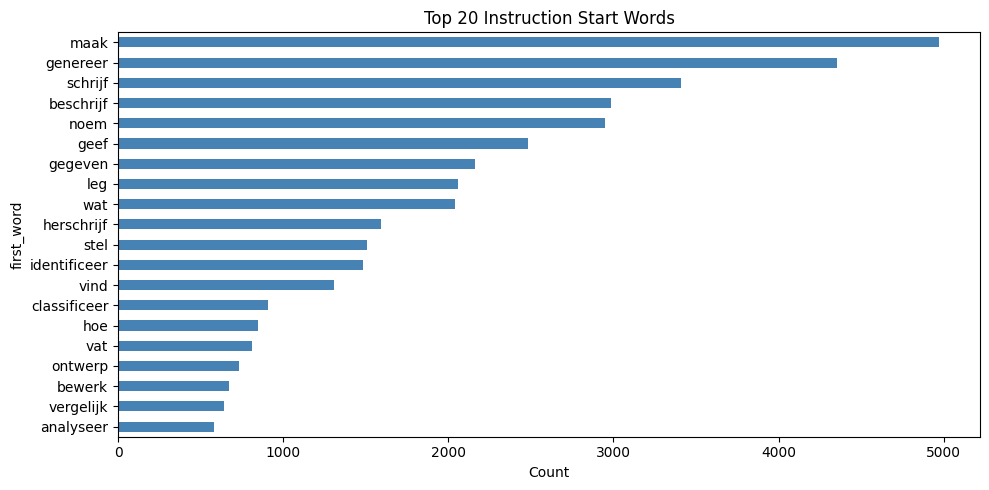

In [6]:
df["first_word"] = df["instruction"].str.split().str[0].str.lower()
top_words = df["first_word"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 5))
top_words.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Count")
ax.set_title("Top 20 Instruction Start Words")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Token Length Distributions (Mistral Tokenizer)

Using the same tokenizer as the finetuning config: `unsloth/mistral-7b-instruct-v0.3-bnb-4bit`

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("unsloth/mistral-7b-instruct-v0.3-bnb-4bit")
print(f"Tokenizer: {tokenizer.__class__.__name__}  |  Vocab size: {tokenizer.vocab_size:,}")

Tokenizer: LlamaTokenizerFast  |  Vocab size: 32,768


In [8]:
# Tokenize instruction+input (prompt side) and output separately
def count_tokens(text):
    return len(tokenizer.encode(text, add_special_tokens=False))

# Build combined prompt the same way as training
df["prompt"] = (df["instruction"].fillna("") + "\n" + df["input"].fillna("")).str.strip()

print("Tokenizing prompts...")
df["prompt_tokens"] = df["prompt"].apply(count_tokens)
print("Tokenizing outputs...")
df["output_tokens"] = df["output"].apply(count_tokens)
df["total_tokens"] = df["prompt_tokens"] + df["output_tokens"]

print("Done!")

Tokenizing prompts...
Tokenizing outputs...
Done!


In [9]:
# Token stats summary
MAX_SEQ_LEN = 2048  # from qlora_config.json

print("=== Token Length Stats ===")
for col, label in [("prompt_tokens", "Prompt (instruction+input)"),
                    ("output_tokens", "Output"),
                    ("total_tokens", "Total (prompt+output)")]:
    s = df[col]
    print(f"\n  {label}:")
    print(f"    min={s.min():>5,}  p25={s.quantile(0.25):>6,.0f}  median={s.median():>6,.0f}  "
          f"p75={s.quantile(0.75):>6,.0f}  p95={s.quantile(0.95):>6,.0f}  max={s.max():>6,}")

n_over = (df["total_tokens"] > MAX_SEQ_LEN).sum()
print(f"\nRows exceeding max_seq_length ({MAX_SEQ_LEN}): {n_over:,} ({100*n_over/len(df):.2f}%)")

=== Token Length Stats ===

  Prompt (instruction+input):
    min=    3  p25=    18  median=    25  p75=    36  p95=    68  max= 1,035

  Output:
    min=    1  p25=    22  median=    75  p75=   155  p95=   283  max= 1,201

  Total (prompt+output):
    min=    6  p25=    55  median=   107  p75=   184  p95=   321  max= 1,539

Rows exceeding max_seq_length (2048): 0 (0.00%)


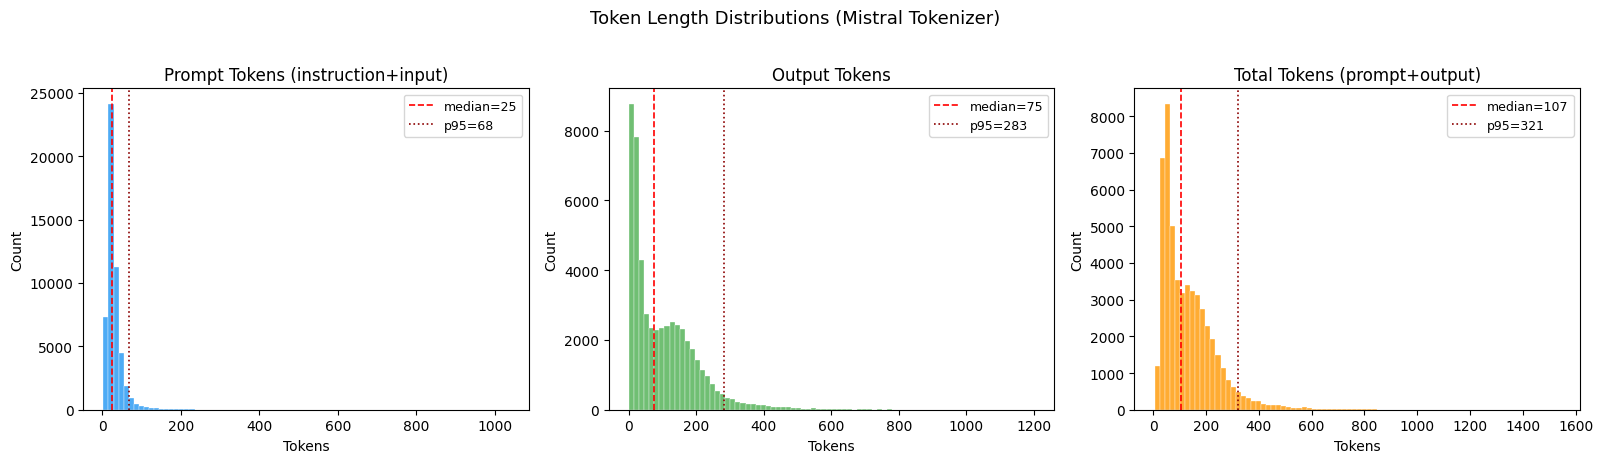

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col, title, color in zip(
    axes,
    ["prompt_tokens", "output_tokens", "total_tokens"],
    ["Prompt Tokens (instruction+input)", "Output Tokens", "Total Tokens (prompt+output)"],
    ["#2196F3", "#4CAF50", "#FF9800"],
):
    data = df[col]
    ax.hist(data, bins=80, color=color, alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axvline(data.median(), color="red", linestyle="--", linewidth=1.2, label=f"median={data.median():.0f}")
    ax.axvline(data.quantile(0.95), color="darkred", linestyle=":", linewidth=1.2, label=f"p95={data.quantile(0.95):.0f}")
    ax.set_title(title)
    ax.set_xlabel("Tokens")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.suptitle("Token Length Distributions (Mistral Tokenizer)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Output token length buckets
buckets = [(0, 10), (10, 25), (25, 50), (50, 100), (100, 200), (200, 500), (500, 2000)]
print("=== Output Token Length Buckets ===")
for lo, hi in buckets:
    count = ((df["output_tokens"] >= lo) & (df["output_tokens"] < hi)).sum()
    pct = 100 * count / len(df)
    bar = "█" * int(pct)
    print(f"  {lo:>4}-{hi:<5} tokens: {count:>6,} ({pct:>5.1f}%) {bar}")

=== Output Token Length Buckets ===
     0-10    tokens:  4,671 (  9.0%) █████████
    10-25    tokens:  9,239 ( 17.9%) █████████████████
    25-50    tokens:  7,745 ( 15.0%) ██████████████
    50-100   tokens:  8,021 ( 15.5%) ███████████████
   100-200   tokens: 14,686 ( 28.4%) ████████████████████████████
   200-500   tokens:  6,959 ( 13.5%) █████████████
   500-2000  tokens:    390 (  0.8%) 


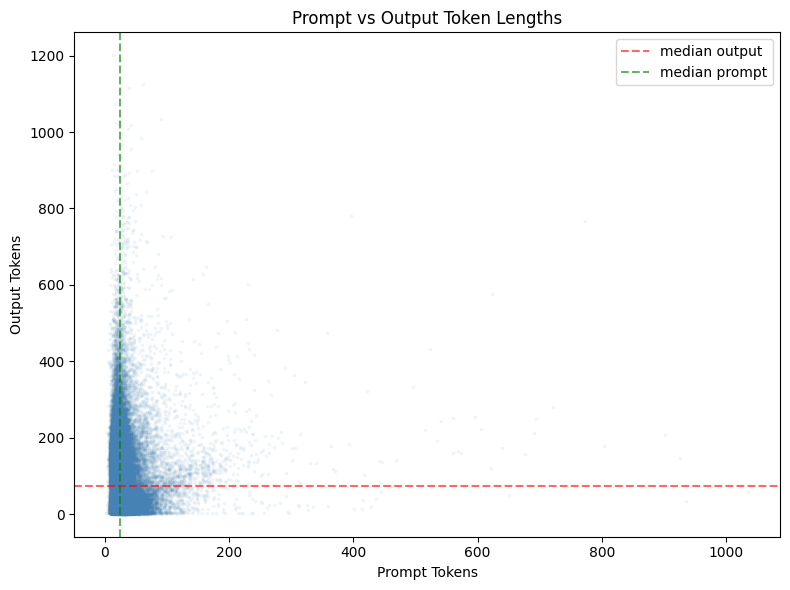

In [12]:
# Scatter: prompt tokens vs output tokens
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["prompt_tokens"], df["output_tokens"], alpha=0.05, s=3, color="steelblue")
ax.axhline(y=np.median(df["output_tokens"]), color="red", linestyle="--", alpha=0.6, label="median output")
ax.axvline(x=np.median(df["prompt_tokens"]), color="green", linestyle="--", alpha=0.6, label="median prompt")
ax.set_xlabel("Prompt Tokens")
ax.set_ylabel("Output Tokens")
ax.set_title("Prompt vs Output Token Lengths")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Sequences Exceeding `max_seq_length`

In [13]:
over = df[df["total_tokens"] > MAX_SEQ_LEN].sort_values("total_tokens", ascending=False)
if len(over) > 0:
    print(f"{len(over):,} rows exceed max_seq_length={MAX_SEQ_LEN}. These will be truncated during training.\n")
    print(over[["id", "instruction", "prompt_tokens", "output_tokens", "total_tokens"]].head(10).to_string(index=False))
else:
    print(f"All rows fit within max_seq_length={MAX_SEQ_LEN}. No truncation needed.")

All rows fit within max_seq_length=2048. No truncation needed.


## 7. Summary

In [14]:
print("=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)
print(f"Total rows:                        {len(df):>8,}")
print(f"Empty instructions:                {(df['instruction'].fillna('').str.strip() == '').sum():>8,}")
print(f"Empty outputs:                     {(df['output'].fillna('').str.strip() == '').sum():>8,}")
print(f"Duplicate instructions:            {df.duplicated(subset=['instruction']).sum():>8,}")
print(f"English leakage (any):             {(df['eng_count'] > 0).sum():>8,}  ({100*(df['eng_count'] > 0).mean():.1f}%)")
print(f"English leakage (heavy, 3+):       {(df['eng_count'] >= 3).sum():>8,}")
print(f"Very short outputs (≤5 chars):     {(df['output'].str.len() <= 5).sum():>8,}")
print(f"")
print(f"Median prompt tokens:              {df['prompt_tokens'].median():>8,.0f}")
print(f"Median output tokens:              {df['output_tokens'].median():>8,.0f}")
print(f"Median total tokens:               {df['total_tokens'].median():>8,.0f}")
print(f"Exceeding max_seq_length ({MAX_SEQ_LEN}):  {(df['total_tokens'] > MAX_SEQ_LEN).sum():>8,}")
print("=" * 60)

DATA QUALITY SUMMARY
Total rows:                          51,711
Empty instructions:                       0
Empty outputs:                            0
Duplicate instructions:                  41
English leakage (any):                1,243  (2.4%)
English leakage (heavy, 3+):            159
Very short outputs (≤5 chars):          925

Median prompt tokens:                    25
Median output tokens:                    75
Median total tokens:                    107
Exceeding max_seq_length (2048):         0
